# Actividad 11 — GC1: SARIMA (Grupo de Control Base)

**Fase 3 — Entrenamiento de Modelos**  
**Proyecto:** Predicción de Demanda Agroindustrial — Limón Peruano  

## Objetivo
Entrenar el modelo de línea base **SARIMA** (GC1) sobre la serie univariada de producción mensual nacional,
aplicando búsqueda automática de parámetros con `auto_arima`, sin data leakage.

## Protocolo de validación
- Split **cronológico estricto 80/20** — sin aleatorización
- `auto_arima` se ajusta **únicamente** sobre el conjunto de entrenamiento
- Las predicciones se generan en un único paso hacia adelante (multi-step forecast)
- Los datos están en **escala z-score** (normalizados en Fase 2): las métricas se reportan en esas mismas unidades

## Outputs
```
resultados/gc1/
  ├── gc1_sarima_model.pkl
  ├── gc1_sarima_metricas.json
  ├── gc1_sarima_predicciones.csv
  ├── gc1_serie_temporal.png
  ├── gc1_split_cronologico.png
  └── gc1_sarima_prediccion_vs_real.png
```

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.facecolor'] = 'white'

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Rutas del proyecto
PROYECTO_ROOT = Path(r'C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-')
DATASET_PATH  = PROYECTO_ROOT / 'data' / 'processed' / 'master_dataset_fase2_multivariado.csv'
RESULTADOS_DIR = PROYECTO_ROOT / 'resultados' / 'gc1'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros del experimento
SPLIT_RATIO     = 0.80
SEASONAL_PERIOD = 12   # mensual
RANDOM_STATE    = 42
ALPHA_CI        = 0.05 # intervalo de confianza 95%

print(f"Dataset   : {DATASET_PATH}")
print(f"Resultados: {RESULTADOS_DIR}")

Dataset   : C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\data\processed\master_dataset_fase2_multivariado.csv
Resultados: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\resultados\gc1


## 2. Carga del dataset

In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['fecha_evento'])

print(f"Filas × columnas  : {df.shape[0]:,} × {df.shape[1]}")
print(f"Rango temporal    : {df['fecha_evento'].min().date()} → {df['fecha_evento'].max().date()}")
print(f"Departamentos     : {df['departamento'].nunique()}")
print(f"Provincias        : {df['provincia'].nunique()}")
print(f"\nColumnas disponibles:")
print(list(df.columns))
df.head(3)

Filas × columnas  : 5,880 × 24
Rango temporal    : 2021-01-01 → 2025-08-01
Departamentos     : 23
Provincias        : 105

Columnas disponibles:
['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'hectareas_cultivo_perdidas', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'lat', 'lon', 'month_sin', 'month_cos', 'mes_num', 'trimestre_num', 'trimestre_sin', 'trimestre_cos']


,fecha_evento,departamento,provincia,produccion_t,precio_chacra_kg,num_emergencias,total_afectados,hectareas_cultivo_perdidas,ALLSKY_SFC_SW_DWN,PRECTOTCORR,...,T2M_MIN,WS2M,lat,lon,month_sin,month_cos,mes_num,trimestre_num,trimestre_sin,trimestre_cos
0,2021-01-01,AMAZONAS,BAGUA,-0.197656,0.156650,0.360646,0.213194,-0.013941,-0.945428,-0.202610,...,0.469032,0.204645,-5.638889,-78.531111,0.500000,8.660254e-01,1,1,1.0,6.123234e-17
1,2021-02-01,AMAZONAS,BAGUA,-0.187033,-0.393473,0.360646,0.036943,-0.013941,-0.952026,-0.266286,...,0.650497,0.074091,-5.638889,-78.531111,0.866025,5.000000e-01,2,1,1.0,6.123234e-17
2,2021-03-01,AMAZONAS,BAGUA,-0.187614,-0.324707,3.717952,-0.083822,-0.013941,-1.153257,0.497834,...,0.489771,-0.108683,-5.638889,-78.531111,1.000000,6.123234e-17,3,1,1.0,6.123234e-17


## 3. Agregación a serie mensual nacional (media provincial)

Se promedia `produccion_t` sobre todas las provincias para cada período mensual,
obteniendo una única serie temporal univariada que representa la producción nacional como media provincial.

> **Nota:** Se usa `.mean()` en lugar de `.sum()` porque los datos están en escala z-score.
> Sumar z-scores de 105 provincias produce una serie con escala errática y denominadores
> cercanos a cero que inflan artificialmente el MAPE. La media preserva la interpretabilidad.

In [4]:
serie_nacional = (
    df.groupby('fecha_evento')['produccion_t']
    .mean()
    .sort_index()
    .rename('produccion_t_media_provincial')
)

# Asegurar frecuencia mensual explícita
serie_nacional.index = pd.DatetimeIndex(serie_nacional.index, freq='MS')

print(f"Observaciones mensuales: {len(serie_nacional)}")
print(f"Período               : {serie_nacional.index.min().date()} → {serie_nacional.index.max().date()}")
print(f"\nEstadísticas descriptivas (z-score, media provincial):")
print(serie_nacional.describe().round(4))
serie_nacional.head(12)

Observaciones mensuales: 56
Período               : 2021-01-01 → 2025-08-01

Estadísticas descriptivas (z-score, media provincial):
count    56.0000
mean      0.0000
std       0.0705
min      -0.1338
25%      -0.0510
50%      -0.0072
75%       0.0424
max       0.1438
Name: produccion_t_media_provincial, dtype: float64


fecha_evento
2021-01-01    0.027472
2021-02-01    0.051936
2021-03-01    0.065985
2021-04-01    0.044351
2021-05-01    0.020828
2021-06-01   -0.030716
2021-07-01   -0.033467
2021-08-01   -0.035027
2021-09-01   -0.033113
2021-10-01   -0.001960
2021-11-01   -0.003217
2021-12-01    0.013090
Freq: MS, Name: produccion_t_media_provincial, dtype: float64

## 4. Exploración visual de la serie

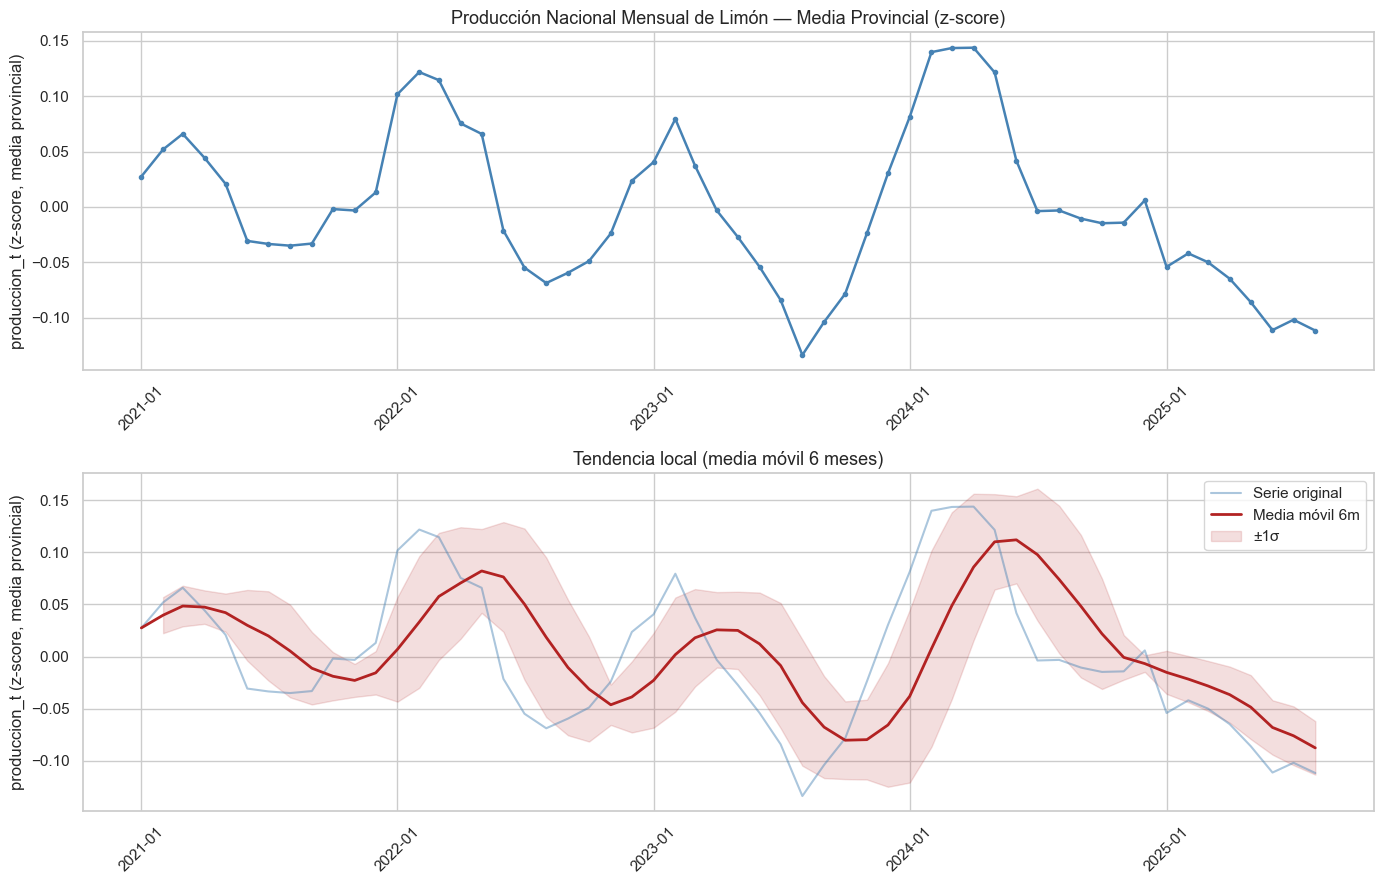

Gráfico guardado → gc1_serie_temporal.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Serie completa ---
axes[0].plot(serie_nacional.index, serie_nacional.values,
             linewidth=1.8, color='steelblue', marker='o', markersize=3)
axes[0].set_title('Producción Nacional Mensual de Limón — Media Provincial (z-score)', fontsize=13)
axes[0].set_ylabel('produccion_t (z-score, media provincial)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# --- Media móvil y banda ---
roll_mean = serie_nacional.rolling(window=6, min_periods=1).mean()
roll_std  = serie_nacional.rolling(window=6, min_periods=1).std()
axes[1].plot(serie_nacional.index, serie_nacional.values,
             alpha=0.45, label='Serie original', color='steelblue')
axes[1].plot(roll_mean.index, roll_mean.values,
             label='Media móvil 6m', color='firebrick', linewidth=2)
axes[1].fill_between(roll_std.index,
                      roll_mean - roll_std, roll_mean + roll_std,
                      alpha=0.15, color='firebrick', label='±1σ')
axes[1].set_title('Tendencia local (media móvil 6 meses)', fontsize=13)
axes[1].set_ylabel('produccion_t (z-score, media provincial)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc1_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado → gc1_serie_temporal.png")

## 5. Split cronológico 80/20

El corte es **estrictamente temporal**: los primeros 80% de meses forman el entrenamiento
y los últimos 20% forman la prueba. No se aplica ninguna aleatorización.

In [6]:
n_total = len(serie_nacional)
n_train = int(n_total * SPLIT_RATIO)
n_test  = n_total - n_train

y_train = serie_nacional.iloc[:n_train]
y_test  = serie_nacional.iloc[n_train:]
split_date = serie_nacional.index[n_train]

print("=" * 55)
print(f"  Total observaciones : {n_total}")
print(f"  Entrenamiento (80%) : {n_train} meses")
print(f"    desde {y_train.index.min().date()} → {y_train.index.max().date()}")
print(f"  Prueba (20%)        : {n_test} meses")
print(f"    desde {y_test.index.min().date()} → {y_test.index.max().date()}")
print(f"  Corte cronológico   : {split_date.date()}")
print("=" * 55)
print("\nSplit cronológico estricto — sin aleatorización ni data leakage.")

  Total observaciones : 56
  Entrenamiento (80%) : 44 meses
    desde 2021-01-01 → 2024-08-01
  Prueba (20%)        : 12 meses
    desde 2024-09-01 → 2025-08-01
  Corte cronológico   : 2024-09-01

Split cronológico estricto — sin aleatorización ni data leakage.


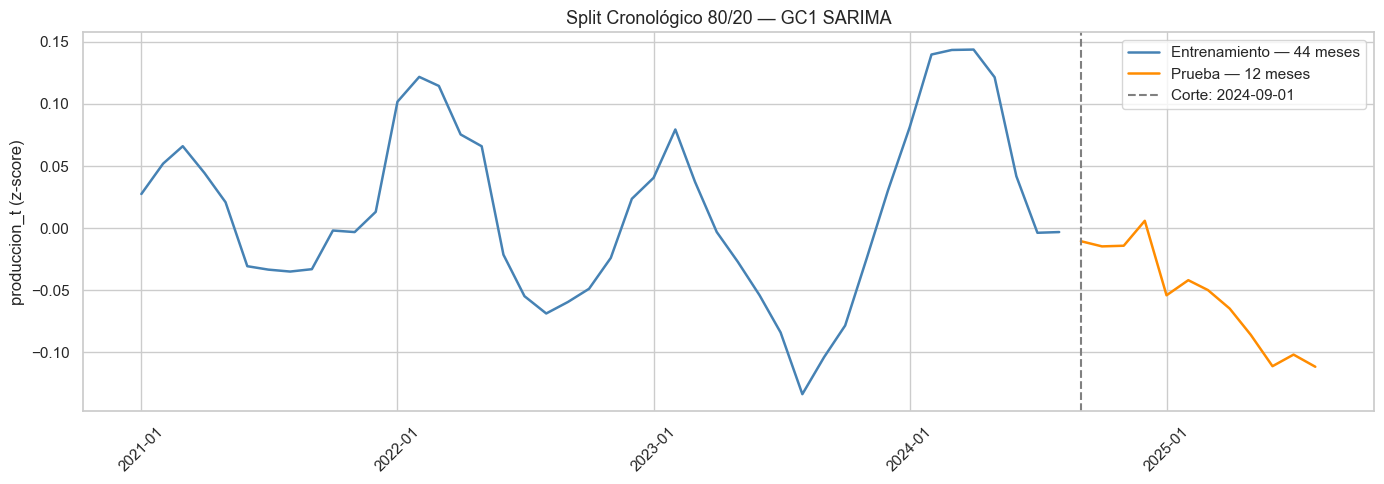

Gráfico guardado → gc1_split_cronologico.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index, y_train.values,
        label=f'Entrenamiento — {n_train} meses', color='steelblue', linewidth=1.8)
ax.plot(y_test.index, y_test.values,
        label=f'Prueba — {n_test} meses', color='darkorange', linewidth=1.8)
ax.axvline(split_date, color='gray', linestyle='--', linewidth=1.5,
           label=f'Corte: {split_date.date()}')
ax.set_title('Split Cronológico 80/20 — GC1 SARIMA', fontsize=13)
ax.set_ylabel('produccion_t (z-score)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc1_split_cronologico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado → gc1_split_cronologico.png")

## 6. Búsqueda automática de parámetros — `auto_arima`

La búsqueda se realiza **exclusivamente sobre `y_train`**.
El criterio de selección es **AIC** con búsqueda *stepwise* (eficiente en tiempo).

Espacio de búsqueda:
- No estacional: p ∈ [0,3], d ∈ auto, q ∈ [0,3]
- Estacional (m=12): P ∈ [0,2], D ∈ auto, Q ∈ [0,2]

In [8]:
print("Iniciando búsqueda de parámetros SARIMA con auto_arima...")
print("(Ajuste ÚNICAMENTE sobre el conjunto de entrenamiento — sin acceso a datos de prueba)\n")

model_search = auto_arima(
    y_train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,              # detección automática del orden de diferenciación
    seasonal=True,
    m=SEASONAL_PERIOD,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,              # detección automática de diferenciación estacional
    information_criterion='aic',
    stepwise=True,
    random_state=RANDOM_STATE,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    n_jobs=-1
)

print(f"\n{'='*50}")
print(f"  Mejor orden SARIMA : {model_search.order}")
print(f"  Orden estacional   : {model_search.seasonal_order}")
print(f"  AIC                : {model_search.aic():.4f}")
print(f"{'='*50}")

Iniciando búsqueda de parámetros SARIMA con auto_arima...
(Ajuste ÚNICAMENTE sobre el conjunto de entrenamiento — sin acceso a datos de prueba)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-78.045, Time=0.03 sec


 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-130.277, Time=0.27 sec


 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-78.941, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-125.351, Time=0.05 sec


 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-131.543, Time=0.30 sec


 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=-129.814, Time=0.50 sec


...

 ARIMA(1,0,0)(1,1,1)[12]             : AIC=inf, Time=0.30 sec
 ARIMA(0,0,0)(2,1,0)[12]             : AIC=-95.113, Time=0.19 sec


 ARIMA(2,0,0)(2,1,0)[12]             : AIC=-130.701, Time=0.42 sec


 ARIMA(1,0,1)(2,1,0)[12]             : AIC=-130.707, Time=0.28 sec


 ARIMA(0,0,1)(2,1,0)[12]             : AIC=-112.443, Time=0.40 sec


 ARIMA(2,0,1)(2,1,0)[12]             : AIC=-128.793, Time=0.43 sec

Best model:  ARIMA(1,0,0)(2,1,0)[12]          
Total fit time: 7.679 seconds

  Mejor orden SARIMA : (1, 0, 0)
  Orden estacional   : (2, 1, 0, 12)
  AIC                : -132.6158


In [9]:
print(model_search.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   44
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                  70.308
Date:                            Mon, 25 May 2026   AIC                           -132.616
Time:                                    13:54:56   BIC                           -126.753
Sample:                                01-01-2021   HQIC                          -130.672
                                     - 08-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9271      0.112      8.301      0.000       0.708       1.146
ar.S.L12      -0.8982      0.270   

## 7. Predicciones sobre el conjunto de prueba

Se generan `n_test` predicciones en un único bloque hacia adelante (*multi-step forecast*).
El modelo no tiene acceso a los valores reales del período de prueba durante la predicción.

In [10]:
print(f"Generando {n_test} predicciones multi-step sobre el conjunto de prueba...")

forecasts, conf_int = model_search.predict(
    n_periods=n_test,
    return_conf_int=True,
    alpha=ALPHA_CI
)

y_pred   = pd.Series(forecasts,        index=y_test.index, name='prediccion')
ci_lower = pd.Series(conf_int[:, 0],   index=y_test.index, name='ci_lower_95')
ci_upper = pd.Series(conf_int[:, 1],   index=y_test.index, name='ci_upper_95')

comparacion = pd.DataFrame({
    'real'       : y_test.values,
    'prediccion' : y_pred.values,
    'ci_lower'   : ci_lower.values,
    'ci_upper'   : ci_upper.values,
    'error_abs'  : np.abs(y_test.values - y_pred.values)
}, index=y_test.index)

print("\nPrimeras 10 predicciones:")
print(comparacion.head(10).round(4).to_string())

Generando 12 predicciones multi-step sobre el conjunto de prueba...

Primeras 10 predicciones:
                real  prediccion  ci_lower  ci_upper  error_abs
fecha_evento                                                   
2024-09-01   -0.0106     -0.0000   -0.0409    0.0409     0.0106
2024-10-01   -0.0147      0.0208   -0.0350    0.0765     0.0355
2024-11-01   -0.0142      0.0299   -0.0360    0.0958     0.0441
2024-12-01    0.0059      0.0566   -0.0170    0.1301     0.0507
2025-01-01   -0.0542      0.1168    0.0373    0.1963     0.1710
2025-02-01   -0.0420      0.1439    0.0596    0.2282     0.1859
2025-03-01   -0.0500      0.1247    0.0365    0.2129     0.1746
2025-04-01   -0.0649      0.0870   -0.0044    0.1784     0.1518
2025-05-01   -0.0860      0.0697   -0.0244    0.1638     0.1557
2025-06-01   -0.1113     -0.0005   -0.0968    0.0959     0.1108


## 8. Cálculo de métricas

Todas las métricas se calculan **solo sobre el conjunto de prueba**.
Los valores están en escala z-score (unidades normalizadas de Fase 2).

In [11]:
def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8) -> float:
    """MAPE protegido contra denominadores cercanos a cero (datos normalizados)."""
    mask = np.abs(y_true) > epsilon
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


y_true_arr = y_test.values
y_pred_arr = y_pred.values

mae  = mean_absolute_error(y_true_arr, y_pred_arr)
rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))
mape = safe_mape(y_true_arr, y_pred_arr)
r2   = r2_score(y_true_arr, y_pred_arr)

metricas = {
    'modelo'           : 'GC1_SARIMA',
    'orden'            : str(model_search.order),
    'orden_estacional' : str(model_search.seasonal_order),
    'aic'              : round(model_search.aic(), 4),
    'n_train'          : int(n_train),
    'n_test'           : int(n_test),
    'split_date'       : str(split_date.date()),
    'MAE'              : round(mae,  6),
    'RMSE'             : round(rmse, 6),
    'MAPE_pct'         : round(mape, 4) if not np.isnan(mape) else None,
    'R2'               : round(r2,   6),
    'nota'             : 'metricas en escala z-score (serie normalizada Fase 2)'
}

print("=" * 52)
print("  MÉTRICAS GC1 — SARIMA  (conjunto de prueba)")
print("=" * 52)
print(f"  Modelo             : SARIMA{model_search.order} × {model_search.seasonal_order}")
print(f"  AIC (train)        : {metricas['aic']}")
print(f"  MAE                : {mae:.6f}")
print(f"  RMSE               : {rmse:.6f}")
print(f"  MAPE               : {mape:.4f} %" if not np.isnan(mape) else "  MAPE  : N/A (valores ≈ 0)")
print(f"  R²                 : {r2:.6f}")
print("=" * 52)
print("  NOTA: métricas en unidades z-score.")

  MÉTRICAS GC1 — SARIMA  (conjunto de prueba)
  Modelo             : SARIMA(1, 0, 0) × (2, 1, 0, 12)
  AIC (train)        : -132.6158
  MAE                : 0.100639
  RMSE               : 0.117860
  MAPE               : 270.5880 %
  R²                 : -7.864449
  NOTA: métricas en unidades z-score.


## 9. Persistencia del modelo y resultados

In [12]:
# Modelo entrenado
model_path = RESULTADOS_DIR / 'gc1_sarima_model.pkl'
joblib.dump(model_search, model_path)

# Métricas en JSON
metricas_path = RESULTADOS_DIR / 'gc1_sarima_metricas.json'
with open(metricas_path, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

# Predicciones en CSV
pred_path = RESULTADOS_DIR / 'gc1_sarima_predicciones.csv'
comparacion.reset_index().rename(columns={'index': 'fecha'}).to_csv(pred_path, index=False)

print(f"Modelo guardado        → {model_path.name}")
print(f"Métricas guardadas     → {metricas_path.name}")
print(f"Predicciones guardadas → {pred_path.name}")
print(f"\nDirectorio: {RESULTADOS_DIR}")

Modelo guardado        → gc1_sarima_model.pkl
Métricas guardadas     → gc1_sarima_metricas.json
Predicciones guardadas → gc1_sarima_predicciones.csv

Directorio: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\resultados\gc1


## 10. Gráfico: Predicción vs Real

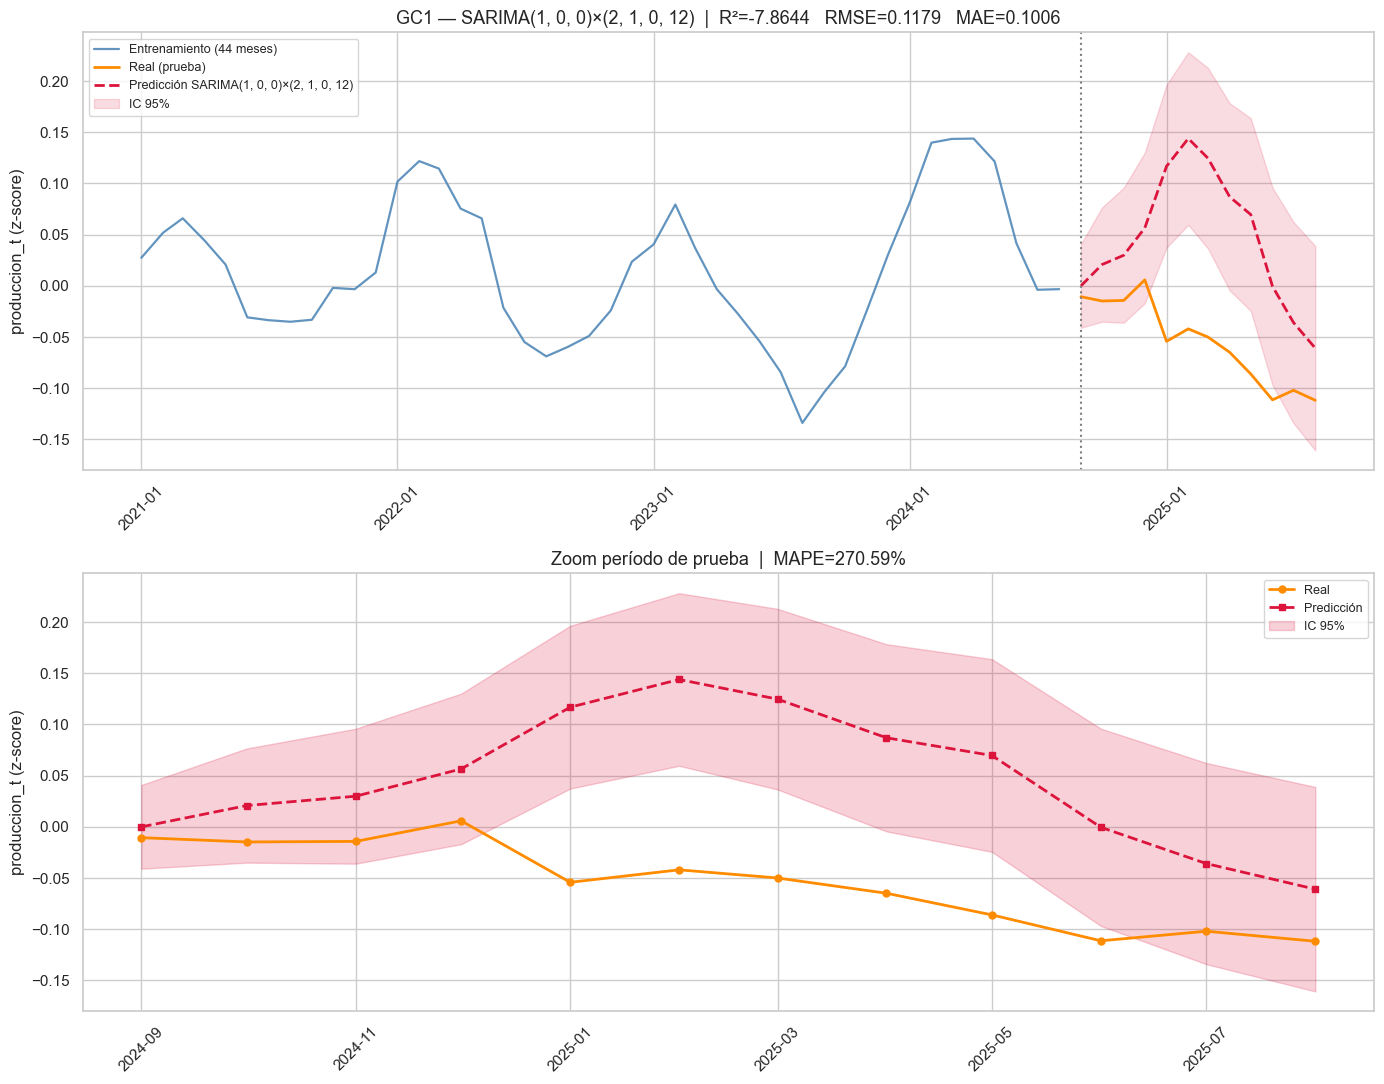

Gráfico guardado → gc1_sarima_prediccion_vs_real.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
titulo_modelo = f"SARIMA{model_search.order}×{model_search.seasonal_order}"

# --- Panel superior: serie completa ---
axes[0].plot(y_train.index, y_train.values,
             label=f'Entrenamiento ({n_train} meses)',
             color='steelblue', linewidth=1.6, alpha=0.85)
axes[0].plot(y_test.index, y_test.values,
             label='Real (prueba)',
             color='darkorange', linewidth=2)
axes[0].plot(y_pred.index, y_pred.values,
             label=f'Predicción {titulo_modelo}',
             color='crimson', linewidth=2, linestyle='--')
axes[0].fill_between(y_test.index, ci_lower, ci_upper,
                      alpha=0.15, color='crimson', label='IC 95%')
axes[0].axvline(split_date, color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title(
    f'GC1 — {titulo_modelo}  |  R²={r2:.4f}   RMSE={rmse:.4f}   MAE={mae:.4f}',
    fontsize=13
)
axes[0].set_ylabel('produccion_t (z-score)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# --- Panel inferior: zoom al período de prueba ---
axes[1].plot(y_test.index, y_test.values,
             label='Real',
             color='darkorange', linewidth=2, marker='o', markersize=5)
axes[1].plot(y_pred.index, y_pred.values,
             label=f'Predicción',
             color='crimson', linewidth=2, linestyle='--', marker='s', markersize=5)
axes[1].fill_between(y_test.index, ci_lower, ci_upper,
                      alpha=0.2, color='crimson', label='IC 95%')
axes[1].set_title(
    f'Zoom período de prueba  |  MAPE={mape:.2f}%' if not np.isnan(mape)
    else 'Zoom período de prueba',
    fontsize=13
)
axes[1].set_ylabel('produccion_t (z-score)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plot_path = RESULTADOS_DIR / 'gc1_sarima_prediccion_vs_real.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado → {plot_path.name}")

## 11. Resumen final

In [14]:
print("\n" + "=" * 52)
print("  RESUMEN GC1 — SARIMA")
print("=" * 52)
for k, v in metricas.items():
    print(f"  {k:<22}: {v}")
print("=" * 52)

archivos = list(RESULTADOS_DIR.iterdir())
print(f"\nArchivos en resultados/gc1/ ({len(archivos)} archivos):")
for f in sorted(archivos):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>7.1f} KB")


  RESUMEN GC1 — SARIMA
  modelo                : GC1_SARIMA
  orden                 : (1, 0, 0)
  orden_estacional      : (2, 1, 0, 12)
  aic                   : -132.6158
  n_train               : 44
  n_test                : 12
  split_date            : 2024-09-01
  MAE                   : 0.100639
  RMSE                  : 0.11786
  MAPE_pct              : 270.588
  R2                    : -7.864449
  nota                  : metricas en escala z-score (serie normalizada Fase 2)

Archivos en resultados/gc1/ (6 archivos):
  gc1_sarima_metricas.json                          0.3 KB
  gc1_sarima_model.pkl                          12173.8 KB
  gc1_sarima_prediccion_vs_real.png               250.9 KB
  gc1_sarima_predicciones.csv                       1.4 KB
  gc1_serie_temporal.png                          261.1 KB
  gc1_split_cronologico.png                       100.9 KB
